# Goal of Feature Engineering

transform raw features into features that better separate fraud from non-fraud.

In [1]:
import numpy as np
import pandas as pd

In [3]:
train = pd.read_pickle(
    "../data/interim/train_optimized.pkl"
)

print(train.shape)

(590540, 434)


In [4]:
train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=434)

In [5]:
missing_pct = train.isnull().mean() * 100

high_missing_cols = missing_pct[
    missing_pct > 95
].sort_values(ascending=False)

high_missing_cols.index.tolist()


['id_24',
 'id_25',
 'id_07',
 'id_08',
 'id_21',
 'id_26',
 'id_22',
 'id_23',
 'id_27']

In [6]:
high_missing_features = high_missing_cols.index.tolist()

for col in high_missing_features:

    train[f"{col}_missing"] = (
        train[col].isnull().astype(np.int8)
    )

/tmp/ipykernel_1191/2104313733.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_missing"] = (
/tmp/ipykernel_1191/2104313733.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_missing"] = (
/tmp/ipykernel_1191/2104313733.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()

In [7]:
train.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,DeviceInfo,id_24_missing,id_25_missing,id_07_missing,id_08_missing,id_21_missing,id_26_missing,id_22_missing,id_23_missing,id_27_missing
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,1,1,1,1,1,1,1,1,1
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,1,1,1,1,1,1,1,1,1
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,1,1,1,1,1,1,1,1,1
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,1,1,1,1,1,1,1,1,1
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,SAMSUNG SM-G892A Build/NRD90M,1,1,1,1,1,1,1,1,1


#### Frequency columns

In [8]:
freq_cols = [
    "DeviceInfo",
    "id_30",
    "id_31",
    "id_33",
    "P_emaildomain",
    "R_emaildomain"
]

for col in freq_cols:

    freq_map = train[col].value_counts()

    train[f"{col}_freq"] = train[col].map(freq_map)

/tmp/ipykernel_1191/1456894073.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_freq"] = train[col].map(freq_map)
/tmp/ipykernel_1191/1456894073.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_freq"] = train[col].map(freq_map)
/tmp/ipykernel_1191/1456894073.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fra

In [9]:
new_freq_cols = [f"{col}_freq" for col in freq_cols]

train[new_freq_cols].head()

,DeviceInfo_freq,id_30_freq,id_31_freq,id_33_freq,P_emaildomain_freq,R_emaildomain_freq
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,228355.0,NaN
2,NaN,NaN,NaN,NaN,5096.0,NaN
3,NaN,NaN,NaN,NaN,100934.0,NaN
4,9.0,2871.0,1061.0,544.0,228355.0,NaN


In [10]:
train.shape

(590540, 449)

#### TransactionAmt Log Transformation

In [11]:
# TransactionAmt Features
train["TransactionAmt_log"] = np.log1p(
    train["TransactionAmt"]
)

/tmp/ipykernel_1191/3367064894.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["TransactionAmt_log"] = np.log1p(


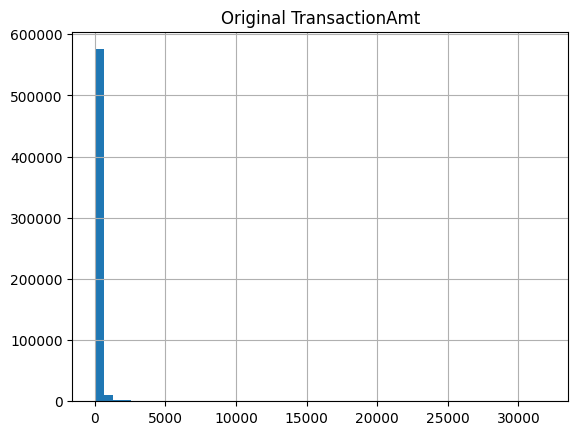

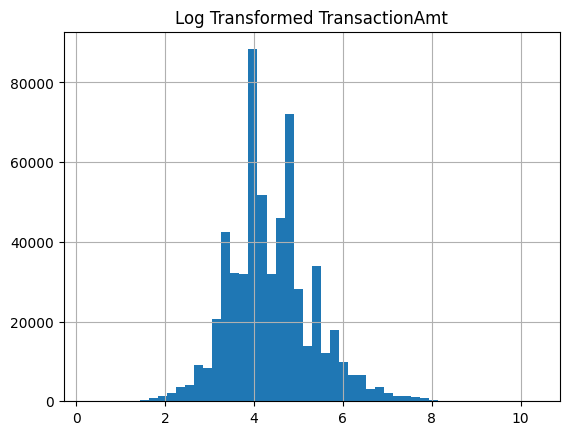

In [12]:
import matplotlib.pyplot as plt

train["TransactionAmt"].hist(bins=50)
plt.title("Original TransactionAmt")
plt.show()

train["TransactionAmt_log"].hist(bins=50)
plt.title("Log Transformed TransactionAmt")
plt.show()

#### Same Email Domain

In [13]:
train["same_email_domain"] = (
    train["P_emaildomain"].astype(str) == train["R_emaildomain"].astype(str)
).astype(np.int8)

/tmp/ipykernel_1191/629721187.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["same_email_domain"] = (


In [14]:
train["same_email_domain"].value_counts()

same_email_domain
0    488036
1    102504
Name: count, dtype: int64

#### Missing Count Features

In [15]:
train["num_missing"] = (
    train.isnull().sum(axis=1)
)

/tmp/ipykernel_1191/1339147464.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["num_missing"] = (


In [16]:
print(train.shape)

(590540, 452)


In [17]:
train[
    [
        "TransactionAmt_log",
        "same_email_domain",
        "num_missing"
    ]
].head()

,TransactionAmt_log,same_email_domain,num_missing
0,4.241327,0,240
1,3.401197,0,235
2,4.094345,0,216
3,3.931826,0,232
4,3.931826,0,138


### Card-Based feature engineering where card1-card6 are payment card-related features

In [18]:
card_cols = [
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6"
]

for col in card_cols:
    print(col, train[col].nunique())

card1 13553
card2 500
card3 114
card4 4
card5 119
card6 4


#### Creating combined card features

In [19]:
# train["card1_card2"] = (
#     train["card1"].astype(str) + "_" + train["card2"].astype(str)
# )

# train["card1_card3"] = (
#     train["card1"].astype(str) + "_" + train["card3"].astype(str)
# )

# train["card1_card5"] = (
#     train["card1"].astype(str) + "_" + train["card5"].astype(str)
# )

for col in ["card2", "card3", "card5"]:

    train[f"card1_{col}"] = (
        train["card1"].fillna(-999).astype(str)
        + "_"
        + train[col].fillna(-999).astype(str)
    )

/tmp/ipykernel_1191/2753891968.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"card1_{col}"] = (
/tmp/ipykernel_1191/2753891968.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"card1_{col}"] = (
/tmp/ipykernel_1191/2753891968.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

In [20]:
# Frequency encoding those combined features

combo_cols = [
    "card1_card2",
    "card1_card3",
    "card1_card5",
]

for col in combo_cols:
    freq_map = train[col].value_counts()

    train[f"{col}_freq"] = train[col].map(freq_map)

/tmp/ipykernel_1191/2735896811.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_freq"] = train[col].map(freq_map)
/tmp/ipykernel_1191/2735896811.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f"{col}_freq"] = train[col].map(freq_map)
/tmp/ipykernel_1191/2735896811.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fra

In [21]:
print(train.shape)

(590540, 458)


#### Measure the Fraud Rates

In [22]:
for col in ["card4", "card6"]:

    print(f"\n{col}")
    
    print(
        train.groupby(col)["isFraud"].mean().sort_values(ascending=False)
    )


card4
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64

card6
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


In [23]:
train.to_pickle(
    "../data/processed/train_fe_v1.pkl"
)

### Aggregation Features

#### Mean Transaction per card1

In [24]:
train["card1_amt_mean"] = train.groupby("card1")["TransactionAmt"].transform("mean")

/tmp/ipykernel_1191/1013352476.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_amt_mean"] = train.groupby("card1")["TransactionAmt"].transform("mean")


#### Standard Deviation per Card1

In [25]:
train["card1_amt_std"] = train.groupby(
    "card1"
)["TransactionAmt"].transform("std")

/tmp/ipykernel_1191/3104199049.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_amt_std"] = train.groupby(


In [26]:
# Fill NaNs
train["card1_amt_std"] = (
    train["card1_amt_std"].fillna(0)
)

#### Maximum Transaction amount per card1

In [27]:
train["card1_amt_max"] = train.groupby(
    "card1"
)["TransactionAmt"].transform("max")

/tmp/ipykernel_1191/271147852.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_amt_max"] = train.groupby(


#### Transaction Count per Card1

In [28]:
train["card1_txn_count"] = train.groupby(
    "card1"
)["TransactionAmt"].transform("count")

/tmp/ipykernel_1191/2567863079.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_txn_count"] = train.groupby(


#### Relative Amount Feature

In [29]:
train["amt_to_card1_mean_ratio"] = (
    train["TransactionAmt"] / (train["card1_amt_mean"] + 1e-5)
)

/tmp/ipykernel_1191/192254259.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["amt_to_card1_mean_ratio"] = (


#### Mean Transaction per Card1_Card2

In [30]:
train["card1_card2_amt_mean"] = train.groupby(
    "card1_card2"
)["TransactionAmt"].transform("mean")

/tmp/ipykernel_1191/3616642524.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_card2_amt_mean"] = train.groupby(


#### Transaction count per Card1_Card2

In [31]:
train["card1_card2_txn_count"] = train.groupby(
    "card1_card2"
)["TransactionAmt"].transform("count")

/tmp/ipykernel_1191/294423742.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_card2_txn_count"] = train.groupby(


In [32]:
print(train.shape)

(590540, 465)


In [33]:
train.to_pickle(
    "../data/processed/train_fe_v2.pkl"
)

In [34]:
train[
    [
        "TransactionAmt",
        "card1_amt_mean",
        "card1_amt_std",
        "card1_txn_count",
        "amt_to_card1_mean_ratio"
    ]
].head()

,TransactionAmt,card1_amt_mean,card1_amt_std,card1_txn_count,amt_to_card1_mean_ratio
0,68.5,351.931152,371.141266,43,0.194640
1,29.0,234.292755,460.356964,683,0.123777
2,59.0,97.015541,100.128860,1108,0.608150
3,50.0,123.416344,192.717422,4209,0.405133
4,50.0,96.972221,56.629452,18,0.515612


TransactionAmt          = 68.5
card1_amt_mean          = 351.93
card1_txn_count         = 43
amt_to_card1_mean_ratio = 0.1946

What it says is that :
This transaction is much smaller than the historical average amount for that card.

In [35]:
train[
    [
        "TransactionAmt",
        "card1_card2_amt_mean",
        "card1_card2_txn_count"
    ]
].head()

,TransactionAmt,card1_card2_amt_mean,card1_card2_txn_count
0,68.5,257.916656,6
1,29.0,235.020782,678
2,59.0,96.791008,1104
3,50.0,123.308487,4197
4,50.0,96.972221,18


In [37]:
train.shape

(590540, 465)

#### Deviation Features

In [ ]:
train["amt_minus_card1_mean"] = (
    train["TransactionAmt"] - train["card1_amt_mean"]
)

# A large postive z-score means: "This transaction is very unusual for this card."
train["amt_zscore_card1"] = (
    train["TransactionAmt"] - train["card1_amt_mean"]
) / (
    train["card1_amt_std"] + 1e-5
)

/tmp/ipykernel_1191/1924701989.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["amt_minus_card1_mean"] = (
/tmp/ipykernel_1191/1924701989.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["amt_zscore_card1"] = (


#### Address Features

In [39]:
train["addr1_addr2"] = (
    train["addr1"].fillna(-999).astype(str)
    + "_"
    + train["addr2"].fillna(-999).astype(str)
)

# frequency encoding of "addr1_addr2" feature
freq_map = train["addr1_addr2"].value_counts()

train["addr1_addr2_freq"] = (
    train["addr1_addr2"].map(freq_map)
)

/tmp/ipykernel_1191/2935981968.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["addr1_addr2"] = (
/tmp/ipykernel_1191/2935981968.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["addr1_addr2_freq"] = (


#### Card + Address Combination

In [40]:
train["card1_addr1"] = (
    train["card1"].fillna(-999).astype(str)
    + "_"
    + train["addr1"].fillna(-999).astype(str)
)

# frequency encoding of "card1_addr1" feature
freq_map = train["card1_addr1"].value_counts()

train["card1_addr1_freq"] = (
    train["card1_addr1"].map(freq_map)
)

/tmp/ipykernel_1191/3937167413.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_addr1"] = (
/tmp/ipykernel_1191/3937167413.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["card1_addr1_freq"] = (


In [42]:
train.shape

(590540, 471)

In [41]:
train.to_pickle(
    "../data/processed/train_fe_final.pkl"
)